# SPX RTH 收盘收敛区间：四模型前向比较

## tl;dr

- 数据仍为 29 个完整 RTH；前 15 日训练，随后 14 日逐日扩展样本外。
- Online pool 的 MAE 为 6.51 点，略差于 RV-scaled 的 6.46；CRPS 为 4.809，略优于 4.863。两项 session-cluster 95% 区间均跨零，没有整体 edge。
- Whole-path analog 的点预测 MAE 最低（6.32），但 CRPS 4.94、80% 覆盖仅 73.6%，说明区间偏窄。
- Online pool 的当前相邻 5 点档 Pin Brier 为 0.2086，对 RV-scaled 的差值 -0.0163，95% 区间未跨零；但这是多指标探索，且相对 Student-t 基线没有显著，不能形成 Pin 交易结论。
- Online pool 区间随收盘临近总体收窄（Spearman ρ=0.891），原始 80% 覆盖 77.9%，均宽 21.47 点。
- 结论仍为 `not_yet_validated`，`ACTION_AUTHORITY=NONE`。

## Context & Methods

问题是：完全脱离现有策略规则，仅凭因果 SPX/ES 路径，哪种小样本方法能最好地更新最终 RTH 收盘分布。

### Key Assumptions

- 目标是收盘前最后一个可观察 SPX 报价，而不是稍后发布的官方 settlement。
- 每个测试日只使用更早交易日；不随机拆分日内行。
- 四个固定研究方法为：日内季节性 Student-t、整路径 Analog、二阶 Functional Prefix→Suffix Ridge，以及只使用以往 OOS CRPS 的收缩在线集成。
- 保留经验分布、RV-scaled 和 spot-zero 作为基线。
- 2,000 次 Monte Carlo 抽样不增加独立交易日数量。
- Pin 事件定义为：收盘落在决策时 SPX 最近 5 点 strike 的 ±2.5 点内；它不代表 dealer 持仓。

In [1]:
from pathlib import Path
import json
import runpy
from IPython.display import HTML, SVG, display

script_path = Path("docs/notebooks/spx-close-convergence-monte-carlo-2026-08-22.py")
module = runpy.run_path(str(script_path))
artifact = module["run_analysis"](write_outputs=False)
print(json.dumps({"data_profile": artifact["data_profile"], "conclusion": artifact["conclusion"]}, ensure_ascii=False, indent=2))

{
  "data_profile": {
    "complete_sessions": 29,
    "first_session": "2026-07-13",
    "last_session": "2026-08-21",
    "median_spx_coverage": 1.0,
    "median_es_coverage": 1.0,
    "samples": 290,
    "oos_sessions": 14,
    "oos_rows_per_method": 140
  },
  "conclusion": {
    "status": "not_yet_validated",
    "summary": "The close distribution is measurable, but the four-model comparison has not cleared all paired OOS and calibration gates.",
    "production_eligible": false,
    "action_authority": "NONE"
  }
}


## Data

Schwab live SPX/ES 原始更新被聚合为一分钟因果桶。仅 SPX 与 ES 分钟覆盖均达到 95% 的完整 RTH 进入样本；决策时间戳与曲线位置在运行时强制对齐。

In [2]:
display(HTML(module["_table_html"]([artifact["data_profile"]], ("complete_sessions", "first_session", "last_session", "median_spx_coverage", "median_es_coverage", "samples", "oos_sessions"))))
print(json.dumps(artifact["leakage_checks"], ensure_ascii=False, indent=2))

complete_sessions,first_session,last_session,median_spx_coverage,median_es_coverage,samples,oos_sessions
29,2026-07-13,2026-08-21,1.0000,1.0000,290,14


{
  "split_unit": "exchange_session",
  "training_dates_strictly_precede_test_date": true,
  "random_intraday_split_used": false,
  "production_strategy_inputs_used": false,
  "target_close_in_feature_matrix": false
}


## Results

MAE、CRPS、Pin Brier 越低越好。80% coverage 需要同时接近 0.80；只把区间做窄不算能力。

In [3]:
columns = ("method", "n", "session_count", "mean_absolute_error_points", "raw_80_coverage", "raw_mean_width_points", "conformal_80_coverage", "conformal_mean_width_points", "crps_points", "pin_brier")
display(HTML(module["_table_html"](artifact["overall_metrics"], columns)))

method,n,session_count,mean_absolute_error_points,raw_80_coverage,raw_mean_width_points,conformal_80_coverage,conformal_mean_width_points,crps_points,pin_brier
empirical,140,14,6.5050,0.9143,31.1054,0.9778,32.9687,5.0995,0.2349
functional_ridge,140,14,6.7729,0.7786,21.0946,0.9222,32.0862,5.1564,0.2100
online_pool,140,14,6.5122,0.7786,21.4733,0.9111,28.4589,4.8089,0.2086
rv_scaled,140,14,6.4644,0.8071,22.4996,0.9444,28.3465,4.8632,0.2250
seasonal_student_t,140,14,6.8147,0.8286,23.1025,0.9333,30.0466,4.9829,0.2114
spot_zero,140,14,6.8545,—,—,—,—,—,—
whole_path_analog,140,14,6.3212,0.7357,19.5346,0.9444,30.2544,4.9354,0.2219


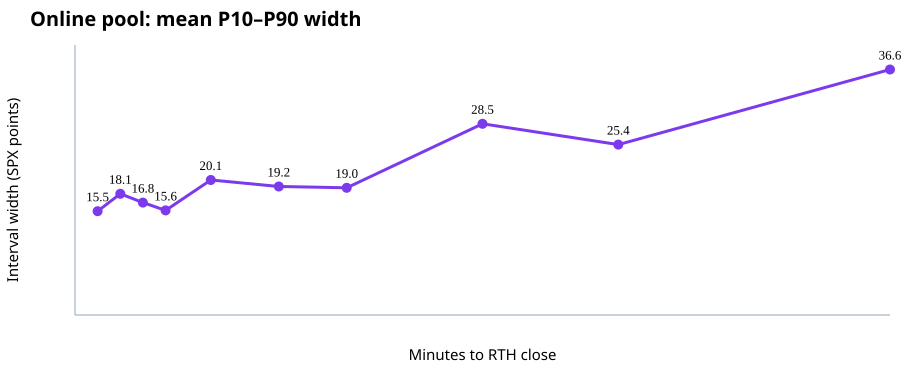

horizon_minutes,n,mean_absolute_error_points,raw_80_coverage,mean_width_points,crps_points,pin_brier
180,14,11.8374,0.7143,36.6060,8.6695,0.1236
120,14,7.2472,0.8571,25.4200,5.2952,0.2242
90,14,8.3730,0.8571,28.5098,5.8394,0.0757
60,14,5.5248,0.7143,18.9760,4.3490,0.1892
45,14,6.3670,0.7143,19.1632,4.5327,0.2053
30,14,5.2843,0.7857,20.1374,3.9921,0.2352
20,14,5.4303,0.7857,15.6001,4.0326,0.2711
15,14,5.4893,0.7857,16.7592,4.1595,0.2026
10,14,5.6452,0.7143,18.0750,4.1716,0.2650
5,14,3.9236,0.8571,15.4864,3.0476,0.2944


In [4]:
display(SVG(artifact["convergence_svg"]))
display(HTML(module["_table_html"](artifact["horizon_metrics"], ("horizon_minutes", "n", "mean_absolute_error_points", "raw_80_coverage", "mean_width_points", "crps_points", "pin_brier"))))

### 配对不确定性

差值为 Online pool 减基线；负数有利。Bootstrap 以完整交易日为 cluster，避免把同一天十个 horizon 当作十个独立日。

In [5]:
display(HTML(module["_table_html"](artifact["paired_bootstrap"], ("baseline", "metric", "difference_challenger_minus_baseline", "session_cluster_95_interval", "probability_challenger_better", "sessions"))))

baseline,metric,difference_challenger_minus_baseline,session_cluster_95_interval,probability_challenger_better,sessions
rv_scaled,mean_absolute_error,0.0478,"[-0.39193418216769205, 0.5613072867605013]",0.4230,14
rv_scaled,crps,-0.0543,"[-0.47641927707816967, 0.4137775532280011]",0.6060,14
rv_scaled,pin_brier,-0.0163,"[-0.031635033928571435, -0.0022632597321428777]",0.9915,14
seasonal_student_t,mean_absolute_error,-0.3025,"[-0.934506917432195, 0.40389708535124047]",0.8210,14
seasonal_student_t,crps,-0.1740,"[-0.6424637031870065, 0.2408770253445056]",0.7705,14
seasonal_student_t,pin_brier,-0.0027,"[-0.014237087008928579, 0.008426036741071416]",0.6725,14


### 模型支持与最新权重

前三个 OOS 日固定等权；之后的权重只使用同 horizon 的既往 OOS CRPS，并向等权收缩。Analog 的有效路径数低于名义训练日数量，因此必须显示支持度。

In [6]:
print(json.dumps({key: value for key, value in artifact["model_diagnostics"].items() if key != "latest_online_weights"}, ensure_ascii=False, indent=2))
display(HTML(module["_table_html"](artifact["model_diagnostics"]["latest_online_weights"], ("horizon_minutes", "weight_seasonal_student_t", "weight_whole_path_analog", "weight_functional_ridge"))))

{
  "initial_three_oos_sessions_use_equal_pool_weights": true,
  "minimum_effective_analog_paths": 8.49425901217466,
  "median_effective_analog_paths": 11.854313285479599,
  "functional_ranks_observed": [
    2
  ]
}


horizon_minutes,weight_seasonal_student_t,weight_whole_path_analog,weight_functional_ridge
180,0.3529,0.3417,0.3053
120,0.3352,0.3256,0.3392
90,0.3384,0.3362,0.3254
60,0.3358,0.3368,0.3274
45,0.3246,0.3422,0.3332
30,0.3310,0.3413,0.3277
20,0.3393,0.3432,0.3174
15,0.3299,0.3412,0.3289
10,0.3300,0.3345,0.3355
5,0.3521,0.3233,0.3245


### 最近样本外交易日：2026-08-21

实际最后可观察 SPX 为 7673.68。概率走廊和触及概率来自当时能够使用的历史数据，不是事后拟合策略卡。

In [7]:
display(HTML(module["_table_html"](artifact["latest_session"], ("horizon_minutes", "decision_spx", "p10_close", "p50_close", "p90_close", "observed_close", "nearest_5pt_pin", "pin_probability", "pin_actual"))))

horizon_minutes,decision_spx,p10_close,p50_close,p90_close,observed_close,nearest_5pt_pin,pin_probability,pin_actual
180,7682.2100,7650.5025,7677.7978,7700.4533,7673.6800,7680.0000,0.1885,False
120,7673.2300,7663.1586,7670.6830,7679.9589,7673.6800,7675.0000,0.1730,True
90,7671.6500,7663.1320,7670.8254,7678.8015,7673.6800,7670.0000,0.3430,False
60,7680.3500,7667.5155,7677.1836,7688.8368,7673.6800,7680.0000,0.1700,False
45,7678.5300,7666.0655,7675.1640,7685.2275,7673.6800,7680.0000,0.1935,False
30,7679.2400,7670.7724,7677.5598,7686.4466,7673.6800,7680.0000,0.3455,False
20,7681.2400,7671.8545,7679.4274,7685.1872,7673.6800,7680.0000,0.4775,False
15,7683.0800,7675.7314,7681.5324,7687.0536,7673.6800,7685.0000,0.2860,False
10,7685.3200,7678.5675,7683.4955,7689.3534,7673.6800,7685.0000,0.3975,False
5,7677.1600,7671.6079,7676.9764,7681.7870,7673.6800,7675.0000,0.4540,True


In [8]:
recent_touches = [row for row in artifact["latest_touch_probabilities"] if row["horizon_minutes"] in {120, 60, 30, 5}]
display(HTML(module["_table_html"](recent_touches, ("horizon_minutes", "decision_spx", "level", "touch_probability"))))

horizon_minutes,decision_spx,level,touch_probability
120,7673.2300,7665.0000,0.3520
120,7673.2300,7670.0000,0.7475
120,7673.2300,7675.0000,0.7595
120,7673.2300,7680.0000,0.2680
120,7673.2300,7685.0000,0.0790
60,7680.3500,7670.0000,0.2900
60,7680.3500,7675.0000,0.5720
60,7680.3500,7680.0000,0.8820
60,7680.3500,7685.0000,0.4910
60,7680.3500,7690.0000,0.2335


## Takeaways

1. **收敛概率走廊可稳定计算，但整体预测 edge 尚未成立。** Online pool 的 CRPS 小幅改善被 MAE 回退和宽置信区间抵消。
2. **整路径 Analog 是值得保留的组件。** 它取得最低 MAE，但当前区间偏窄，必须与更分散的模型混合。
3. **Functional Ridge 暂未证明价值。** 在 15–28 个训练日上即使限制为 2 个主成分，仍没有超过简单基线。固定规格继续积累数据，不调参追样本。
4. **Pin Brier 是唯一新的研究线索。** 需要预先冻结 Pin 定义、按 horizon 检查可靠性、处理多重比较，并追加独立日期；不解释为 dealer positioning。
5. **下一门槛**：至少 40–60 个 OOS session；Online pool 相对 RV 与 Student-t 的 MAE、CRPS 上界都小于零，80% 原始覆盖在 72%–88%，才允许讨论策略映射。